In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [10]:
dfd = pd.read_csv(r"C:\Users\rishy\Desktop\New folder\infosys\day.csv")
dfh = pd.read_csv(r"C:\Users\rishy\Downloads\ml\hour.csv")


In [11]:
columns_to_drop_day = ['instant', 'dteday', 'yr', 'casual', 'registered']
dfd.drop(columns=columns_to_drop_day, inplace=True, errors='ignore')

columns_to_drop_hour = ['dteday', 'casual', 'registered', 'yr', 'instant']
dfh = dfh.drop(columns=columns_to_drop_hour, errors='ignore')


In [12]:
dfh = dfh.drop_duplicates()


In [13]:
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']



In [14]:
def remove_outliers_corrected(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df


In [15]:
dfd = remove_outliers_corrected(dfd, numeric_cols)
dfh = remove_outliers_corrected(dfh, numeric_cols)

print("Preprocessing and Outlier Removal Completed.")


Preprocessing and Outlier Removal Completed.


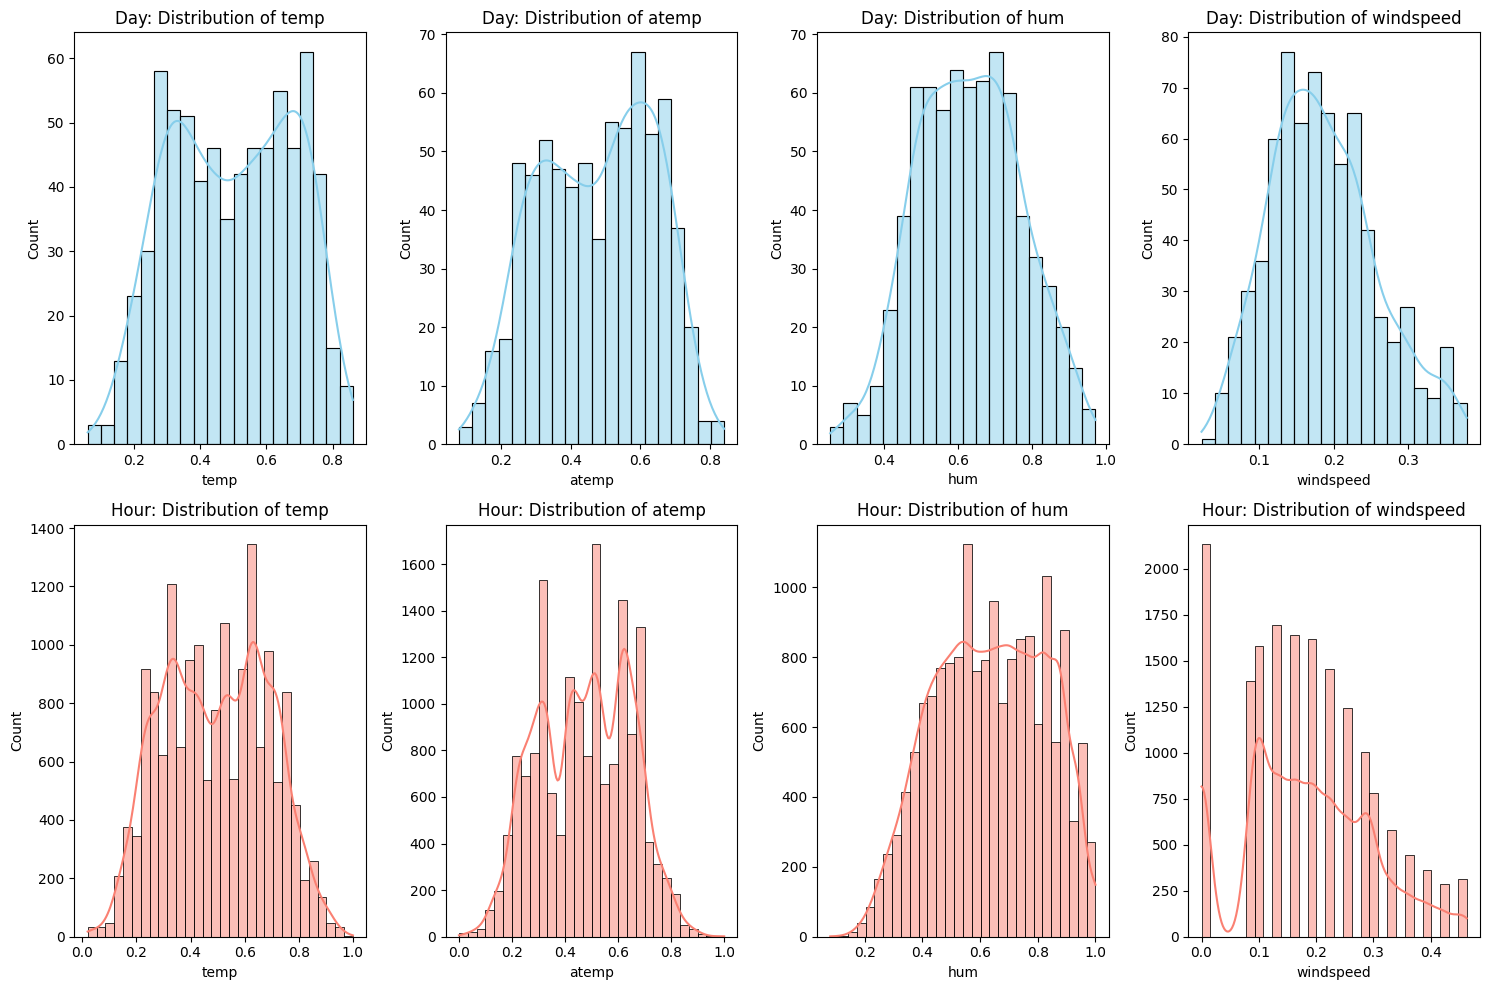

In [18]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols[:-1]): # Exclude 'cnt' for a cleaner distribution view
    plt.subplot(2, 4, i + 1)
    sns.histplot(dfd[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Day: Distribution of {col}')

    plt.subplot(2, 4, i + 5)
    sns.histplot(dfh[col], kde=True, bins=30, color='salmon')
    plt.title(f'Hour: Distribution of {col}')

plt.tight_layout()
plt.show()


In [19]:
X = dfd.drop('cnt', axis=1)
y = dfd['cnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_day = RandomForestRegressor(n_estimators=200, random_state=42)
rf_day.fit(X_train, y_train)
pred_rf_day = rf_day.predict(X_test)
lr_day = LinearRegression()
lr_day.fit(X_train, y_train)
pred_lr_day = lr_day.predict(X_test)


In [20]:
X_h = dfh.drop('cnt', axis=1)
y_h = dfh['cnt']
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
rf_hour = RandomForestRegressor(n_estimators=200, random_state=42)
rf_hour.fit(X_train_h, y_train_h)
pred_rf_hour = rf_hour.predict(X_test_h)
lr_hour = LinearRegression()
lr_hour.fit(X_train_h, y_train_h)
pred_lr_hour = lr_hour.predict(X_test_h)

print("\nModels Trained.")



Models Trained.


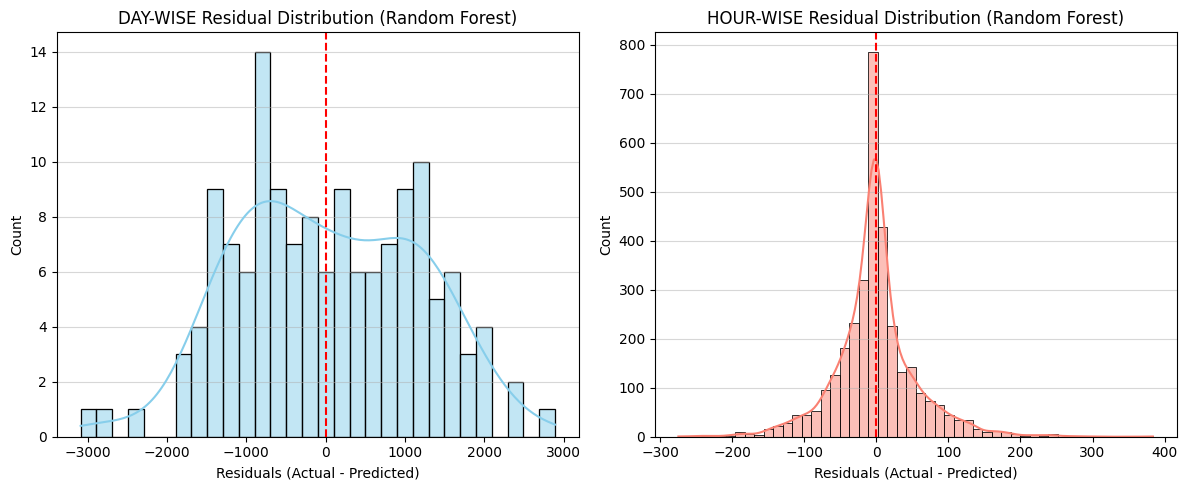

In [23]:
residuals_rf_day = y_test - pred_rf_day
residuals_rf_hour = y_test_h - pred_rf_hour

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_rf_day, kde=True, bins=30, color='skyblue')
plt.title("DAY-WISE Residual Distribution (Random Forest)")
plt.xlabel("Residuals (Actual - Predicted)")
plt.axvline(0, color='red', linestyle='--')
plt.grid(axis='y', alpha=0.5)

plt.subplot(1, 2, 2)
sns.histplot(residuals_rf_hour, kde=True, bins=50, color='salmon')
plt.title("HOUR-WISE Residual Distribution (Random Forest)")
plt.xlabel("Residuals (Actual - Predicted)")
plt.axvline(0, color='red', linestyle='--')
plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()


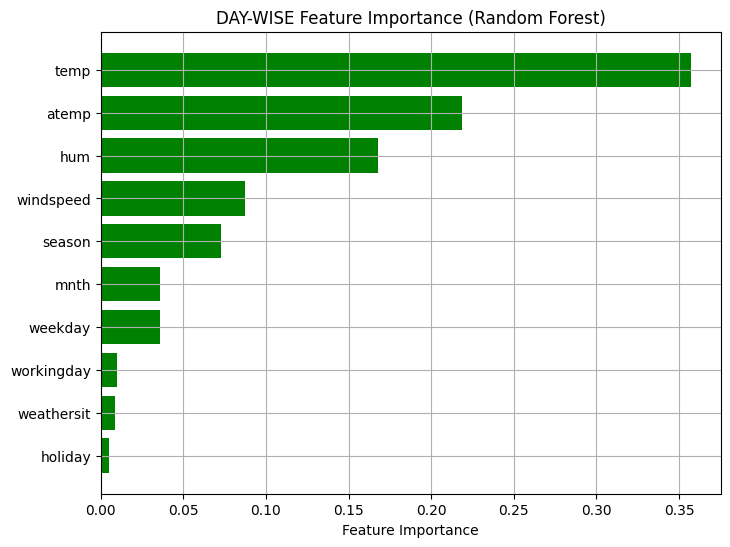

In [25]:
importances_day = rf_day.feature_importances_
feature_names_day = X.columns
fi_day = pd.DataFrame({'Feature': feature_names_day, 'Importance': importances_day}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,6))
plt.barh(fi_day['Feature'], fi_day['Importance'], color='green')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("DAY-WISE Feature Importance (Random Forest)")
plt.grid(True)
plt.show()

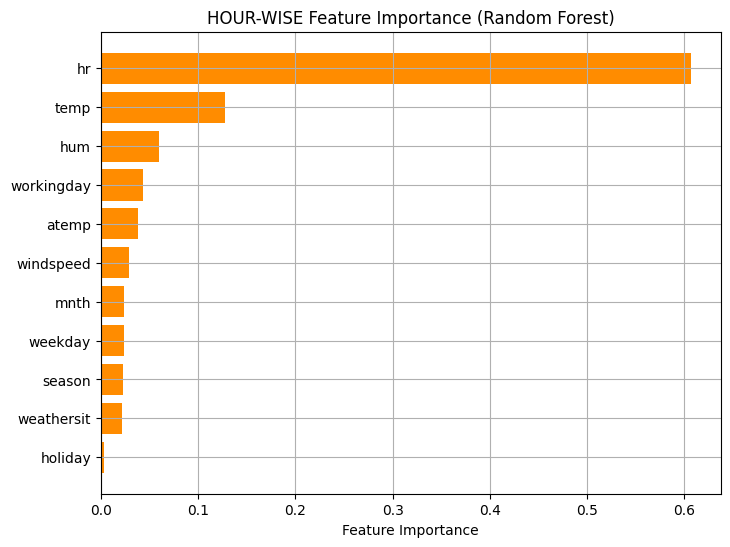

In [26]:
importances_hour = rf_hour.feature_importances_
feature_names_hour = X_h.columns
fi_hour = pd.DataFrame({'Feature': feature_names_hour, 'Importance': importances_hour}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,6))
plt.barh(fi_hour['Feature'], fi_hour['Importance'], color='darkorange')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("HOUR-WISE Feature Importance (Random Forest)")
plt.grid(True)
plt.show()


In [29]:
plt.figure(figsize=(12, 5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

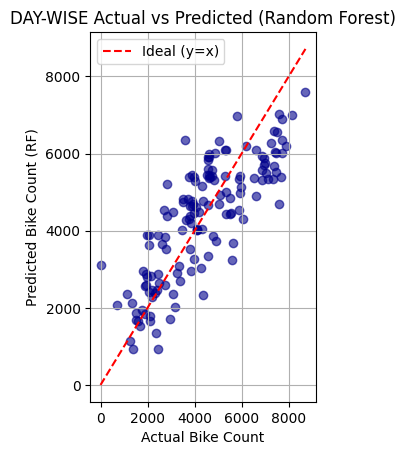

In [30]:
plt.subplot(1, 2, 1)
plt.scatter(y_test.values, pred_rf_day, alpha=0.6, color='darkblue')
max_val_day = max(y_test.max(), pred_rf_day.max())
plt.plot([0, max_val_day], [0, max_val_day], 'r--', label='Ideal (y=x)') # Ideal line
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (RF)")
plt.title("DAY-WISE Actual vs Predicted (Random Forest)")
plt.legend()
plt.grid(True)


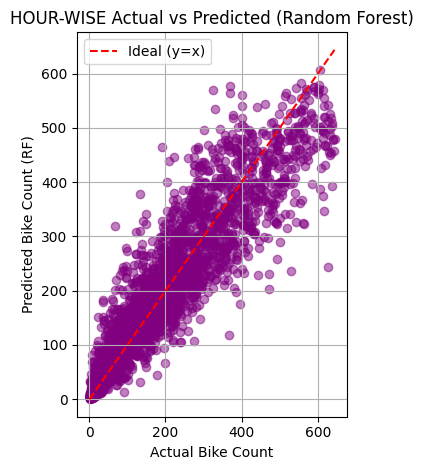

In [31]:
plt.subplot(1, 2, 2)
plt.scatter(y_test_h.values, pred_rf_hour, alpha=0.5, color='purple')
max_val_hour = max(y_test_h.max(), pred_rf_hour.max())
plt.plot([0, max_val_hour], [0, max_val_hour], 'r--', label='Ideal (y=x)') # Ideal line
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (RF)")
plt.title("HOUR-WISE Actual vs Predicted (Random Forest)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



In [32]:
plt.figure(figsize=(12, 5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

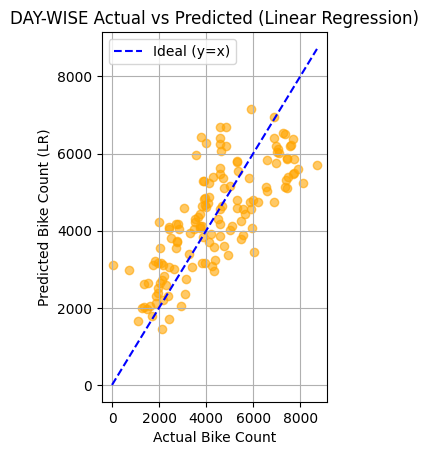

In [33]:
plt.subplot(1, 2, 1)
plt.scatter(y_test.values, pred_lr_day, alpha=0.6, color='orange')
max_val_day = max(y_test.max(), pred_lr_day.max())
plt.plot([0, max_val_day], [0, max_val_day], 'b--', label='Ideal (y=x)')
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (LR)")
plt.title("DAY-WISE Actual vs Predicted (Linear Regression)")
plt.legend()
plt.grid(True)


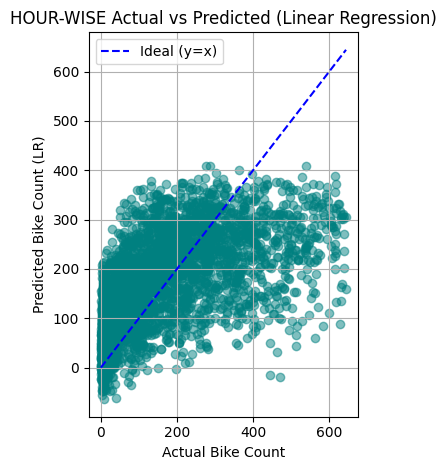


All new diagrams have been generated.


In [34]:
plt.subplot(1, 2, 2)
plt.scatter(y_test_h.values, pred_lr_hour, alpha=0.5, color='teal')
max_val_hour = max(y_test_h.max(), pred_lr_hour.max())
plt.plot([0, max_val_hour], [0, max_val_hour], 'b--', label='Ideal (y=x)')
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (LR)")
plt.title("HOUR-WISE Actual vs Predicted (Linear Regression)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nAll new diagrams have been generated.")